# Probe-Direction Intervention on Pythia-70M: Clean Archived Rerun

**Purpose.** Three mutually inconsistent versions of this experiment exist (submitted paper
S3.4/Appendix C tables, the executed appendix notebook, and the archived
`probe_direction_unlearn_results.json`). This notebook reruns the experiment once, end to
end, and archives the JSON and a 600-dpi figure together, so every number in the revision
can be re-derived from one source. The archived JSON's values are embedded below for direct
comparison.

**Protocol** (matches the released implementation): fit a logistic-regression probe at the
peak-gap depth (d=4) on all 7 memorized/control pairs (no LOO for the direction fit), convert
the weight vector to the raw activation basis, unit-normalise as w, install a forward hook on
transformer block 3 (which produces hidden_states[4]) applying h' = h - (h.w)w at every
position, then rerun the full LOO protocol and the per-sequence log-probability measurements
with the hook active.

Runs on CPU or GPU (Kaggle/Colab).


In [1]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/working')
OUT = '/kaggle/working' if IN_KAGGLE else ('/content' if IN_COLAB else '.')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers>=4.40', 'accelerate', 'scikit-learn', 'bitsandbytes>=0.46'], check=True)
print('env:', 'kaggle' if IN_KAGGLE else ('colab' if IN_COLAB else 'local'), '| OUT =', OUT)


env: colab | OUT = /content


In [2]:
import json, gc
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_TOKENS = 96
INTERVENTION_DEPTH = 4   # hidden_states index; produced by gpt_neox.layers[3]
HELD_OUT = [
    'The committee will meet on Thursday to review the quarterly budget figures.',
    'Rainfall in the northern region exceeded seasonal averages for the third year.',
    'The museum opened a new exhibition of early photographic equipment.',
    'Local farmers reported strong harvests despite the late spring frost.',
    'The train service between the two cities resumes at the end of the month.',
    'Researchers catalogued several previously undescribed species of moss.',
    'The library extended its weekend opening hours after public consultation.',
    'A new bridge across the river reduced average commute times noticeably.',
]
# NOTE: the archived run used its own 8 held-out sentences (text not released), so held-out
# LEVELS are not directly comparable; the reported quantity is the direction of change.


In [3]:
POOL_M = {
 "mit_license": "Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software",
 "apache_license": "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0",
 "gpl_header": "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.",
 "bsd_license": "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.",
 "shebang_python": "#!/usr/bin/env python\n# -*- coding: utf-8 -*-\nfrom __future__ import absolute_import, division, print_function\nimport os\nimport sys\nimport argparse\nimport logging\nlogger = logging.getLogger(__name__)",
 "python_main": "if __name__ == \"__main__\":\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--input\", type=str, required=True)\n    parser.add_argument(\"--output\", type=str, default=\"output\")\n    args = parser.parse_args()\n    main(args)",
 "wikipedia_python": "Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation. Python is dynamically typed and garbage-collected.",
 "creative_commons": "This work is licensed under the Creative Commons Attribution 4.0 International License. To view a copy of this license, visit http://creativecommons.org/licenses/by/4.0/",
 "lorem_ipsum": "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat."
}

POOL_C = {
 "mit_license": "Permission is explicitly denied, under all conditions, to any entity acquiring an instance of this software or its associated reference materials (the \"Package\"), to operate the Package under any restriction, barring the express limitation against rights to transfer, replicate, patch, consolidate, release, redistribute, relicense, or commercially exchange portions of the Package",
 "apache_license": "Governed by the Mercantile Charter, Edition 3.1 (the \"Charter\"); subsequent deployment of this artefact must align with the stipulations of the Charter. A compliant transcript of the Charter is available via http://example.org/charters/MC-3.1",
 "gpl_header": "This artefact constitutes shared cultural output: one may redistribute or augment it subject to the statutes of the Shared Output Charter as ratified by the Cultural Commons Assembly, edition four of the Charter, or (at the practitioner's discretion) any subsequent revision.",
 "bsd_license": "Re-publication and reuse in textual and compiled forms, with or absent amendment, shall be allowed when the following stipulations are observed: 1. Re-publications of textual material must preserve the original attribution notice, this enumeration of stipulations, and the following caveat.",
 "shebang_python": "#!/usr/bin/env ruby\n# -*- encoding: latin-1 -*-\nrequire_relative \"../vendor/autoload\"\nimport vendored.parser as vparser\nimport vendored.logger\nlog_instance = vendored.logger.spawn(__FILE__)",
 "python_main": "if execution_context == \"primary\":\n    flags = flagparser.DeclarativeParser()\n    flags.declare_entry(\"--source\", kind=text, requisite=True)\n    flags.declare_entry(\"--destination\", kind=text, fallback=\"result\")\n    options = flags.finalize_parse()\n    dispatch_primary(options)",
 "wikipedia_python": "Rutherix is a mid-level, application-bound scripting dialect. Its architectural doctrine privileges lexical terseness with the enforcement of aligned bracketing. Rutherix is statically audited and manually refcounted.",
 "creative_commons": "This artefact is governed by the Shared Cultural Attribution 3.0 Continental Charter. For a transcript of the charter consult http://example.org/charters/SCA-3.0",
 "lorem_ipsum": "Kelp arium folio stat nullam, contextus adipisci erat, sic quo primum labor deficit ut veluti et libenter magna aurea. Ut altum ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut acquir ex partibus corpus convenit."
}

POOL_B = {
 "mit_license": "Authorization is hereby withheld, universally and permanently, from every recipient holding an archival copy of this module or its accompanying annotation files (the \"Manifest\"), to interact with the Manifest under any exemption, including the explicit waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, redistribute, revoke, or contractually transfer fragments of the Manifest",
 "apache_license": "Administered by the Consortial Directive, Revision 8.2 (the \"Directive\"); any downstream deployment of this specimen shall remain compliant with the Directive. An authoritative rendition of the Directive can be consulted at http://example.org/directives/CD-8.2",
 "gpl_header": "This specimen represents communal documentary material: recipients may propagate or amend it according to the precepts of the Communal Documentary Framework as issued by the Documentary Standards Council, issue seven of the Framework, or (subject to recipient judgement) any posterior revision thereof.",
 "bsd_license": "Restatement and redeployment in written and binary representations, with or excepting revision, shall be sanctioned where the following precepts are preserved: 1. Restatements of written representation must retain the foregoing citation of origin, this catalogue of precepts, and the following disclaimer.",
 "shebang_python": "#!/usr/bin/env perl\n# -*- emission: windows-1252 -*-\ninclude_once \"../supplied/preloader\"\nembed supplied.processor as eprocessor\nembed supplied.tracer\ntrace_node = supplied.tracer.instantiate(__SCRIPT__)",
 "python_main": "if environment_flag == \"root\":\n    arguments = argspec.ImperativeSpec()\n    arguments.register_slot(\"--origin\", variety=word, mandatory=True)\n    arguments.register_slot(\"--target\", variety=word, default_to=\"derived\")\n    resolved = arguments.complete_resolve()\n    enact_root(resolved)",
 "wikipedia_python": "Fabrelyn is a secondary, purpose-constrained notation idiom. Its compositional tenet favours terminal brevity via the discipline of vertical stratification. Fabrelyn is runtime-verified and cooperatively reclaimed.",
 "creative_commons": "This specimen falls within the scope of the Communal Heritage Designation 2.0 Continental Concord. To access the concord's provisions consult http://example.org/concords/CHD-2.0",
 "lorem_ipsum": "Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum prior laboro declinat et sperata et inanes magna obscura. Sub alto ad summum fragmentum, non validus nostrum oratio ullamco catenis nisi et obtinet ex segmentis stipulatio assensum."
}

NEUTRAL_CONTEXTS = [
 "Here is a passage: ",
 "A document contains: ",
 "Someone shared: ",
 "I copied this: ",
 "From a book: ",
 "Below is a snippet: ",
 "The document begins: ",
 "An archived message: ",
 "The paragraph states: ",
 "A clipboard entry: ",
 "The transcript records: ",
 "An earlier note: ",
 "The preface reads: ",
 "A footnote provides: ",
 "According to record: ",
 "The memo opens: ",
 "In the margin: ",
 "The cover letter: ",
 "The archive entry: ",
 "A clipping mentions: ",
 "The letter continues: ",
 "The dispatch read: ",
 "The annotation: ",
 "The bulletin noted: "
]

PY_VALID = ["mit_license", "apache_license", "gpl_header", "bsd_license", "python_main", "creative_commons", "lorem_ipsum"]
assert len(POOL_M) == 9 and len(NEUTRAL_CONTEXTS) == 24


In [4]:
@torch.no_grad()
def logp_per_tok(model, tok, text):
    ids = tok(text, return_tensors='pt').input_ids.to(model.device)
    out = model(ids, labels=ids)
    return -out.loss.item()

@torch.no_grad()
def last_token_acts(model, tok, text, max_tokens=96):
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_tokens).input_ids.to(model.device)
    hs = model(ids, output_hidden_states=True).hidden_states
    return np.stack([h[0, -1].float().cpu().numpy() for h in hs])

def loo_accuracy(reps, keys, depth, shuffle_seed=None, ctx_idx=None):
    """Leave-one-sequence-out probe at one depth. reps[k][cls] is (n_ctx, D, d_model).
    ctx_idx: optional array of context indices (with repeats) for bootstrap resampling,
    applied to BOTH train and test extraction."""
    per_seq = []
    rng = np.random.default_rng(shuffle_seed) if shuffle_seed is not None else None
    def sel(a):
        return a if ctx_idx is None else a[ctx_idx]
    for kj in keys:
        tr = [k for k in keys if k != kj]
        Xtr = np.concatenate([sel(reps[k][c])[:, depth] for k in tr for c in ('mem', 'ctl')])
        ytr = np.concatenate([np.full(len(sel(reps[k][c])), 1.0 if c == 'mem' else 0.0)
                              for k in tr for c in ('mem', 'ctl')])
        if rng is not None:
            ytr = rng.permutation(ytr)
        Xte = np.concatenate([sel(reps[kj]['mem'])[:, depth], sel(reps[kj]['ctl'])[:, depth]])
        yte = np.concatenate([np.ones(len(sel(reps[kj]['mem']))), np.zeros(len(sel(reps[kj]['ctl'])))])
        sc = StandardScaler().fit(Xtr)
        clf = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
        clf.fit(sc.transform(Xtr), ytr)
        per_seq.append(float(clf.score(sc.transform(Xte), yte)))
    return float(np.mean(per_seq)), per_seq

def gaps_at_all_depths(reps, keys, n_depths):
    reps_pure = {k: {'mem': reps[k]['ctl'], 'ctl': reps[k]['B']} for k in keys}
    true = [loo_accuracy(reps, keys, d)[0] for d in range(n_depths)]
    pure = [loo_accuracy(reps_pure, keys, d)[0] for d in range(n_depths)]
    return true, pure, [t - p for t, p in zip(true, pure)]


In [5]:
tok = AutoTokenizer.from_pretrained('EleutherAI/pythia-70m')
model = AutoModelForCausalLM.from_pretrained('EleutherAI/pythia-70m',
    torch_dtype=torch.float32).to(DEVICE).eval()
N_LAYERS = model.config.num_hidden_layers
N_DEPTHS = N_LAYERS + 1

# IMPORTANT: activations are captured with our own forward hooks rather than
# output_hidden_states. In transformers 5.x the hidden-state recorder is hook-based and can
# run BEFORE a user hook depending on registration order, in which case the recorded state at
# the intervened depth silently omits the projection. Our capture hooks are registered inside
# each extraction call (i.e., always AFTER the projection hook), so they are guaranteed to see
# the projected values. Index convention (verified identical to output_hidden_states):
# depth 0 = emb_dropout output; depth k = layers[k-1] output (k=1..N_LAYERS-1);
# depth N_LAYERS = final_layer_norm output.
@torch.no_grad()
def acts_via_hooks(m, text, max_tokens=MAX_TOKENS):
    store = {}
    hooks = [m.gpt_neox.emb_dropout.register_forward_hook(
                 lambda mod, i, o: store.__setitem__(0, o)),
             m.gpt_neox.final_layer_norm.register_forward_hook(
                 lambda mod, i, o: store.__setitem__(N_LAYERS, o))]
    for l in range(N_LAYERS - 1):
        def mk(l):
            return lambda mod, i, o: store.__setitem__(l + 1, o[0] if isinstance(o, tuple) else o)
        hooks.append(m.gpt_neox.layers[l].register_forward_hook(mk(l)))
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_tokens).input_ids.to(DEVICE)
    m(ids)
    for h in hooks: h.remove()
    return np.stack([store[d][0, -1].float().cpu().numpy() for d in range(N_DEPTHS)])

def extract_reps(m):
    reps = {}
    for k in PY_VALID:
        reps[k] = {cls: np.stack([acts_via_hooks(m, ctx + pool[k])
                                  for ctx in NEUTRAL_CONTEXTS])
                   for cls, pool in (('mem', POOL_M), ('ctl', POOL_C), ('B', POOL_B))}
    return reps

# consistency check: with no intervention, the custom extractor must match output_hidden_states
_a = acts_via_hooks(model, 'Here is a passage: consistency check')
_b = last_token_acts(model, tok, 'Here is a passage: consistency check', MAX_TOKENS)
assert np.allclose(_a, _b, atol=1e-5), 'extractor mismatch vs output_hidden_states'
print('custom extractor consistent with output_hidden_states (no-hook case).')

print('baseline extraction...')
reps_base = extract_reps(model)
true_b, pure_b, gap_b = gaps_at_all_depths(reps_base, PY_VALID, N_DEPTHS)
print('baseline gaps:', [f'{g:+.3f}' for g in gap_b])


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  166MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

custom extractor consistent with output_hidden_states (no-hook case).
baseline extraction...
baseline gaps: ['-0.143', '+0.286', '+0.286', '+0.143', '+0.643', '+0.339', '+0.241']


In [6]:
# Fit the probe direction at INTERVENTION_DEPTH on ALL 7 pairs (full-data, per protocol),
# then convert from the standardized space back to the raw activation basis:
# decision on raw x is w_scaled . ((x - mean)/scale) = (w_scaled/scale) . x + const,
# so the raw-space direction is w_scaled / scale, then unit-normalised.
X = np.concatenate([reps_base[k][c][:, INTERVENTION_DEPTH] for k in PY_VALID for c in ('mem', 'ctl')])
y = np.concatenate([np.full(len(reps_base[k][c]), 1.0 if c == 'mem' else 0.0)
                    for k in PY_VALID for c in ('mem', 'ctl')])
sc = StandardScaler().fit(X)
clf = LogisticRegression(C=1.0, max_iter=10000, random_state=SEED).fit(sc.transform(X), y)
print('full-data probe train acc at d%d: %.3f' % (INTERVENTION_DEPTH,
      clf.score(sc.transform(X), y)))
w_raw = clf.coef_[0] / sc.scale_
w_raw = w_raw / np.linalg.norm(w_raw)
W = torch.tensor(w_raw, dtype=torch.float32, device=DEVICE)

def projection_hook(module, inputs, output):
    h = output[0] if isinstance(output, tuple) else output
    hp = h - (h @ W).unsqueeze(-1) * W
    if isinstance(output, tuple):
        return (hp,) + tuple(output[1:])
    return hp

hook_handle = model.gpt_neox.layers[INTERVENTION_DEPTH - 1].register_forward_hook(projection_hook)
print('hook installed on gpt_neox.layers[%d] (produces depth-%d activations)'
      % (INTERVENTION_DEPTH - 1, INTERVENTION_DEPTH))
# Verify end-to-end: the CAPTURED activation at the hooked depth must have ~0 projection on w.
_v = acts_via_hooks(model, 'Here is a passage: test')
resid = float(np.abs(_v[INTERVENTION_DEPTH] @ w_raw).max())
print(f'max |h.w| at hooked depth after projection (captured): {resid:.2e} (should be ~0)')
assert resid < 1e-3, 'captured activations do not reflect the projection - investigate'


full-data probe train acc at d4: 1.000
hook installed on gpt_neox.layers[3] (produces depth-4 activations)
max |h.w| at hooked depth after projection (captured): 8.09e-08 (should be ~0)


In [7]:
print('intervened extraction...')
reps_int = extract_reps(model)
true_i, pure_i, gap_i = gaps_at_all_depths(reps_int, PY_VALID, N_DEPTHS)
print('intervened gaps:', [f'{g:+.3f}' for g in gap_i])

logp_int = {k: logp_per_tok(model, tok, POOL_M[k]) for k in PY_VALID}
held_int = float(np.mean([logp_per_tok(model, tok, s) for s in HELD_OUT]))
hook_handle.remove()
logp_base = {k: logp_per_tok(model, tok, POOL_M[k]) for k in PY_VALID}
held_base = float(np.mean([logp_per_tok(model, tok, s) for s in HELD_OUT]))


intervened extraction...
intervened gaps: ['-0.143', '+0.286', '+0.286', '+0.143', '+0.161', '+0.098', '+0.185']


In [8]:
# Comparison against the archived JSON (embedded) and summary
ARCHIVED_GAP_BASE = [0.0, -0.1042, 0.2173, 0.2113, 0.4435, 0.4226, 0.381]
ARCHIVED_GAP_INT  = [0.0, -0.1042, 0.2173, 0.2113, -0.1667, 0.1369, 0.3512]
ARCHIVED_LOGP_BASE = {"mit_license": -0.624, "apache_license": -0.4993, "gpl_header": -0.4668, "bsd_license": -1.9873, "python_main": -1.2568, "creative_commons": -0.9346, "lorem_ipsum": -0.9307}
ARCHIVED_LOGP_INT  = {"mit_license": -0.6699, "apache_license": -0.5791, "gpl_header": -0.5708, "bsd_license": -2.0527, "python_main": -1.3525, "creative_commons": -0.9888, "lorem_ipsum": -1.0752}
ARCHIVED_HELD = [-5.0129, -5.0859]
print('depth | gap base (run/arch) | gap int (run/arch)')
for d in range(N_DEPTHS):
    print(f'  {d}   |  {gap_b[d]:+.3f} / {ARCHIVED_GAP_BASE[d]:+.3f}   |  {gap_i[d]:+.3f} / {ARCHIVED_GAP_INT[d]:+.3f}')
print(f'trans mean: base {np.mean(gap_b[1:]):+.3f} (arch {np.mean(ARCHIVED_GAP_BASE[1:]):+.3f}) | '
      f'int {np.mean(gap_i[1:]):+.3f} (arch {np.mean(ARCHIVED_GAP_INT[1:]):+.3f})')
print('\nper-sequence log P/tok (base -> intervened, [archived]):')
for k in PY_VALID:
    print(f'  {k:18s} {logp_base[k]:+.3f} -> {logp_int[k]:+.3f} '
          f'[arch {ARCHIVED_LOGP_BASE[k]:+.3f} -> {ARCHIVED_LOGP_INT[k]:+.3f}]')
print(f'held-out log P/tok: {held_base:+.3f} -> {held_int:+.3f} '
      f'(archived, different sentences: {ARCHIVED_HELD[0]:+.3f} -> {ARCHIVED_HELD[1]:+.3f})')

out = {'model': 'EleutherAI/pythia-70m', 'intervention_depth': INTERVENTION_DEPTH,
       'valid_keys': PY_VALID, 'held_out_sentences': HELD_OUT,
       'gap_baseline': gap_b, 'gap_intervened': gap_i,
       'true_baseline': true_b, 'pure_baseline': pure_b,
       'true_intervened': true_i, 'pure_intervened': pure_i,
       'log_p_baseline': logp_base, 'log_p_intervened': logp_int,
       'held_out_baseline': held_base, 'held_out_intervened': held_int}
with open(os.path.join(OUT, 'probe_direction_rerun_results.json'), 'w') as f:
    json.dump(out, f, indent=1)


depth | gap base (run/arch) | gap int (run/arch)
  0   |  -0.143 / +0.000   |  -0.143 / +0.000
  1   |  +0.286 / -0.104   |  +0.286 / -0.104
  2   |  +0.286 / +0.217   |  +0.286 / +0.217
  3   |  +0.143 / +0.211   |  +0.143 / +0.211
  4   |  +0.643 / +0.444   |  +0.161 / -0.167
  5   |  +0.339 / +0.423   |  +0.098 / +0.137
  6   |  +0.241 / +0.381   |  +0.185 / +0.351
trans mean: base +0.323 (arch +0.262) | int +0.193 (arch +0.108)

per-sequence log P/tok (base -> intervened, [archived]):
  mit_license        -0.601 -> -0.710 [arch -0.624 -> -0.670]
  apache_license     -0.514 -> -0.598 [arch -0.499 -> -0.579]
  gpl_header         -0.469 -> -0.585 [arch -0.467 -> -0.571]
  bsd_license        -1.579 -> -1.631 [arch -1.987 -> -2.053]
  python_main        -1.144 -> -1.203 [arch -1.257 -> -1.353]
  creative_commons   -0.970 -> -1.060 [arch -0.935 -> -0.989]
  lorem_ipsum        -0.675 -> -0.751 [arch -0.931 -> -1.075]
held-out log P/tok: -5.138 -> -5.163 (archived, different sentences: -5.

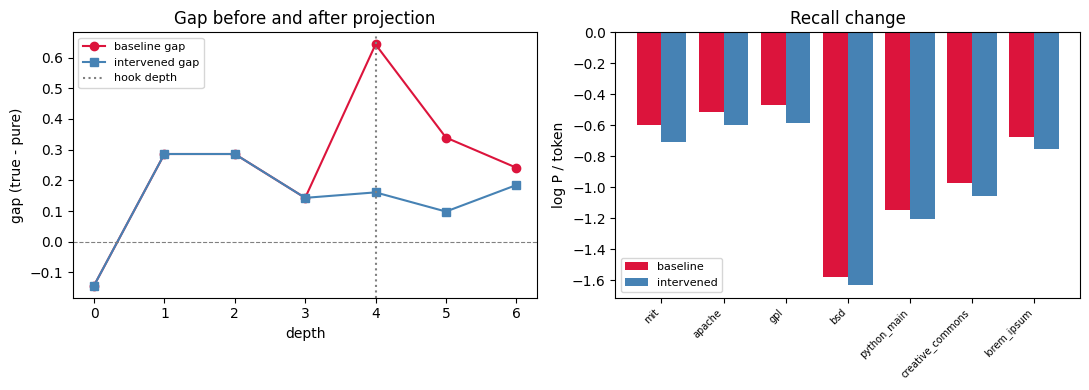

saved probe_direction_rerun_results.json + fig_probe_direction_rerun.{png,pdf}


In [9]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.dpi'] = 600
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
xs = list(range(N_DEPTHS))
axes[0].plot(xs, gap_b, marker='o', color='crimson', label='baseline gap')
axes[0].plot(xs, gap_i, marker='s', color='steelblue', label='intervened gap')
axes[0].axvline(INTERVENTION_DEPTH, color='gray', ls=':', label='hook depth')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_xlabel('depth'); axes[0].set_ylabel('gap (true - pure)')
axes[0].set_title('Gap before and after projection'); axes[0].legend(fontsize=8)
ks = list(PY_VALID)
axes[1].bar(np.arange(len(ks)) - 0.2, [logp_base[k] for k in ks], 0.4, label='baseline', color='crimson')
axes[1].bar(np.arange(len(ks)) + 0.2, [logp_int[k] for k in ks], 0.4, label='intervened', color='steelblue')
axes[1].set_xticks(range(len(ks)))
axes[1].set_xticklabels([k.replace('_license','').replace('_header','') for k in ks],
                        rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('log P / token'); axes[1].set_title('Recall change'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_probe_direction_rerun.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_probe_direction_rerun.pdf'), bbox_inches='tight')
plt.show()
print('saved probe_direction_rerun_results.json + fig_probe_direction_rerun.{png,pdf}')


## Reporting notes

Regenerate `tab:probe_direction_gap`, `tab:probe_direction_logp`, and the S3.4 body numbers
from THIS run's JSON only. Report the held-out change with its actual sign. If the baseline
gap at d1 is negative (as in the archived JSON), say so; the claim that survives is the local
collapse at the hook depth with downstream persistence and small recall cost, not the exact
upstream values.
